# Switched UCA with Centre Reference

This notebook follows on from the ideal UCA simulations and investigates the switched-array architecture. One receive channel is assumed to continuously measure a centre reference antenna, while the second receive channel is switched between the outer UCA elements.

The aim is to determine whether the relative antenna phases can be recovered from sequential measurements and used for direction-of-arrival estimation. Conventional Bartlett beamforming is used throughout as the baseline estimator.

In [93]:
using LinearAlgebra
using Plots
using Random
using Statistics

## 1. Setup and UCA Geometry

A six-element uniform circular array is modelled at 433 MHz with neighbouring antenna spacing of 0.4λ. A centre reference antenna is placed at the origin.

For outer antenna $i$, located at angular position $\phi_i$, the projection of its displacement onto the direction of arrival is

$$
OD_i = R\cos(\phi_0-\phi_i)\sin\theta_0
$$

where $R$ is the array radius, $\phi_0$ is the transmitter azimuth and $\theta_0$ is the elevation angle.

The corresponding propagation-time difference relative to the centre reference is

$$
\Delta t_i = -\frac{OD_i}{c}
$$

and therefore the phase of antenna $i$ relative to the centre reference is

$$
\psi_i = -2\pi f\Delta t_i
       = \frac{2\pi}{\lambda}OD_i.
$$

For the horizontal-plane case used here, $\theta_0=90^\circ$, so this reduces to

$$
\psi_i =
\frac{2\pi R}{\lambda}
\cos(\phi_0-\phi_i).
$$

The transmitter is initially placed at an azimuth of $30^\circ$, and these relative phases are calculated for each outer antenna.

In [128]:
# Physical parameters
c = 3e8                  # Speed of light (m/s)
f = 433e6                # RF frequency (Hz)
λ = c / f                # Wavelength (m)

# Number of outer antennas
N = 6

# Angular position of each antenna
phi = (0:N-1) .* (2 * π / N)

# Desired spacing between neighbouring antennas
d = 0.4 * λ

# Radius of the circular array
R = d / (2 * sin(π / N))

# Antenna coordinates
x = R .* cos.(phi)
y = R .* sin.(phi)

println("Frequency = ", f / 1e6, " MHz")
println("Wavelength = ", λ, " m")
println("Number of outer antennas = ", N)
println("Neighbour spacing = ", d, " m")
println("Array radius = ", R, " m")

Frequency = 433.0 MHz
Wavelength = 0.6928406466512702 m
Number of outer antennas = 6
Neighbour spacing = 0.2771362586605081 m
Array radius = 0.2771362586605082 m


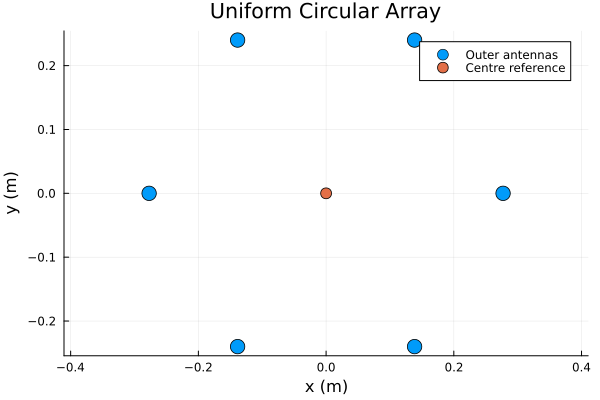

In [129]:
scatter(x, y,
    xlabel = "x (m)",
    ylabel = "y (m)",
    label = "Outer antennas",
    markersize = 8,
    aspect_ratio = :equal,
    title = "Uniform Circular Array")

scatter!([0], [0],
    label = "Centre reference",
    markersize = 6)

In [130]:
# Transmitter direction
phi0_deg = 30
theta0_deg = 60

phi0 = deg2rad(phi0_deg)
theta0 = deg2rad(theta0_deg)

# Path difference relative to the centre
OD = R .* cos.(phi0 .- phi) .* sin(theta0)

# Arrival-time difference relative to the centre
delta_t = -OD ./ c

# Direction-dependent phase at each outer antenna
phase = -2 * π * f .* delta_t

println("Direction phases:")

for i = 1:N
    println(
        "Antenna ", i, ": ",
        round(rad2deg(phase[i]), digits = 2), "°"
    )
end

Direction phases:
Antenna 1: 108.0°
Antenna 2: 108.0°
Antenna 3: 0.0°
Antenna 4: -108.0°
Antenna 5: -108.0°
Antenna 6: -0.0°


## 2. Centre-Reference Phase Recovery

The switched antennas are measured at different times, so the common signal phase may change between switch positions. The centre antenna is measured simultaneously with each selected outer antenna and is used as a phase reference.


In [131]:
# One centre-reference measurement

common_phase_deg = 40
direction_phase_deg = 100

# RX1 measures the centre antenna
centre_signal = exp(im * deg2rad(common_phase_deg))

# RX2 measures one outer antenna
outer_signal = exp(im * deg2rad(common_phase_deg + direction_phase_deg))

# Remove the common phase
recovered = outer_signal * conj(centre_signal)

println("Centre phase      = ", rad2deg(angle(centre_signal)), "°")
println("Outer phase       = ", rad2deg(angle(outer_signal)), "°")
println("Recovered phase   = ", rad2deg(angle(recovered)), "°")

Centre phase      = 40.0°
Outer phase       = 140.0°
Recovered phase   = 100.0°


In [132]:
# Two different switch positions

common_phase_deg = [40, -20]
direction_phase_deg = [100, 60]

centre_signal = exp.(im .* deg2rad.(common_phase_deg))

outer_signal = exp.(im .* deg2rad.(common_phase_deg .+ direction_phase_deg))

recovered = outer_signal .* conj.(centre_signal)

for i = 1:2
    println("Measurement ", i)
    println("  Common phase    = ", common_phase_deg[i], "°")
    println("  Direction phase = ", direction_phase_deg[i], "°")
    println("  Outer phase     = ",
            round(rad2deg(angle(outer_signal[i])), digits=2), "°")
    println("  Recovered phase = ",
            round(rad2deg(angle(recovered[i])), digits=2), "°")
    println()
end

Measurement 1
  Common phase    = 40°
  Direction phase = 100°
  Outer phase     = 140.0°
  Recovered phase = 100.0°

Measurement 2
  Common phase    = -20°
  Direction phase = 60°
  Outer phase     = 40.0°
  Recovered phase = 60.0°



## 3. Ideal Switched UCA

The centre-reference method is now applied to all six outer antennas. A different common phase is used at each switch position to represent sequential measurements.

The recovered phase pattern is compared with the ideal UCA phase pattern, after which Bartlett beamforming is used to estimate the transmitter direction.

In [133]:
# Common phase at each switch position
common_phase_deg = [20, 50, 80, 110, 140, 170]
common_phase = deg2rad.(common_phase_deg)

# RX1 continuously measures the centre antenna
centre_signal = exp.(im .* common_phase)

# RX2 measures one outer antenna at each switch position
outer_signal = exp.(im .* (common_phase .+ phase))

# Recover the direction-dependent phases
recovered = outer_signal .* conj.(centre_signal)

6-element Vector{ComplexF64}:
 -0.30901699437494795 + 0.9510565162951534im
 -0.30901699437494806 + 0.9510565162951533im
                  1.0 + 1.942890293094024e-16im
   -0.309016994374948 - 0.9510565162951534im
  -0.3090169943749481 - 0.9510565162951533im
   0.9999999999999999 - 2.220446049250313e-15im

In [134]:
for i = 1:N
    expected = rad2deg(angle(exp(im * phase[i])))
    recovered_phase = rad2deg(angle(recovered[i]))

    println(
        "Antenna ", i,
        ": expected = ", round(expected, digits=2),
        "°, recovered = ", round(recovered_phase, digits=2), "°"
    )
end

Antenna 1: expected = 108.0°, recovered = 108.0°
Antenna 2: expected = 108.0°, recovered = 108.0°
Antenna 3: expected = 0.0°, recovered = 0.0°
Antenna 4: expected = -108.0°, recovered = -108.0°
Antenna 5: expected = -108.0°, recovered = -108.0°
Antenna 6: expected = -0.0°, recovered = -0.0°


In [135]:
# Bartlett direction scan

phi_test_deg = 0:0.1:359.9
score = zeros(length(phi_test_deg))

for k = 1:length(phi_test_deg)

    phi_test = deg2rad(phi_test_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test
    a_test = exp.(im .* phase_test)

    score[k] = abs(sum(conj.(a_test) .* recovered))
end

phi_est = phi_test_deg[argmax(score)]

println("True direction      = ", phi0_deg, " degrees")
println("Estimated direction = ", phi_est, " degrees")

True direction      = 30 degrees
Estimated direction = 30.0 degrees


## 4. Measurement Noise

Noise is added independently to the centre-reference and switched-antenna measurements. The effect of using a single noisy sample is first examined.

The simulation is then extended to multiple samples per switch position. The centre-referenced complex samples are averaged before direction estimation to reduce the effect of random noise.

In [136]:
# Add noise to both receive channels

SNR_dB = 20
noise_power = 10^(-SNR_dB / 10)

centre_noise = sqrt(noise_power / 2) .* (randn(N) .+ im .* randn(N))

outer_noise = sqrt(noise_power / 2) .* (randn(N) .+ im .* randn(N))

centre_noisy = centre_signal + centre_noise
outer_noisy = outer_signal + outer_noise

# Recover the direction-dependent phases
recovered_noisy = outer_noisy .* conj.(centre_noisy)

6-element Vector{ComplexF64}:
   -0.332728199505353 + 0.9194008467839416im
 -0.31650068864572434 + 1.1036089000939628im
   1.0499724629623215 - 0.07326509722053914im
 -0.24546988804588532 - 1.1398450339224029im
  -0.3602520508360096 - 0.8841602207560857im
   0.8855430512270592 - 0.11869940369707366im

In [137]:
for i = 1:N
    expected = rad2deg(angle(exp(im * phase[i])))
    recovered_phase = rad2deg(angle(recovered_noisy[i]))
    
    println(
        "Antenna ", i,
        ": expected = ", round(expected, digits=2),
        "°, recovered = ", round(recovered_phase, digits=2), "°"
    )
end

Antenna 1: expected = 108.0°, recovered = 109.9°
Antenna 2: expected = 108.0°, recovered = 106.0°
Antenna 3: expected = 0.0°, recovered = -3.99°
Antenna 4: expected = -108.0°, recovered = -102.15°
Antenna 5: expected = -108.0°, recovered = -112.17°
Antenna 6: expected = -0.0°, recovered = -7.63°


In [138]:
Ns = 1000

recovered_average = zeros(ComplexF64, N)

for i = 1:N

    # Ideal centre and outer signals for this switch position
    centre_samples = fill(exp(im * common_phase[i]), Ns)

    outer_samples = fill(exp(im * (common_phase[i] + phase[i])), Ns)

    # Independent noise on both receive channels
    centre_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

    outer_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

    centre_noisy = centre_samples + centre_noise
    outer_noisy = outer_samples + outer_noise

    # Centre-reference every sample, then average
    recovered_samples = outer_noisy .* conj.(centre_noisy)

    recovered_average[i] = mean(recovered_samples)
end

In [139]:
for i = 1:N
    expected = rad2deg(angle(exp(im * phase[i])))
    recovered_phase = rad2deg(angle(recovered_average[i]))

    println(
        "Antenna ", i,
        ": expected = ", round(expected, digits=2),
        "°, averaged = ", round(recovered_phase, digits=2), "°"
    )
end

Antenna 1: expected = 108.0°, averaged = 108.42°
Antenna 2: expected = 108.0°, averaged = 108.37°
Antenna 3: expected = 0.0°, averaged = -0.0°
Antenna 4: expected = -108.0°, averaged = -108.24°
Antenna 5: expected = -108.0°, averaged = -107.92°
Antenna 6: expected = -0.0°, averaged = 0.06°


In [140]:
score = zeros(length(phi_test_deg))

for k = 1:length(phi_test_deg)

    phi_test = deg2rad(phi_test_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test
    a_test = exp.(im .* phase_test)

    score[k] = abs(sum(conj.(a_test) .* recovered_average))
end

phi_est = phi_test_deg[argmax(score)]

println("True direction      = ", phi0_deg, " degrees")
println("Estimated direction = ", phi_est, " degrees")

True direction      = 30 degrees
Estimated direction = 30.0 degrees


The direction estimate from a single noise realisation does not show how consistently the system performs. A Monte Carlo simulation is therefore used to repeat the measurement with independent noise and calculate the mean absolute error (MAE) and root mean square error (RMSE).

In [141]:
# Testing whether the above result are consistent over many random noise realisations


trials = 100
estimates = zeros(trials)

for trial = 1:trials

    recovered_trial = zeros(ComplexF64, N)

    for i = 1:N

        centre_samples = fill(exp(im * common_phase[i]), Ns)

        outer_samples = fill(exp(im * (common_phase[i] + phase[i])), Ns)

        centre_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

        outer_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

        centre_noisy = centre_samples + centre_noise
        outer_noisy = outer_samples + outer_noise

        recovered_samples = outer_noisy .* conj.(centre_noisy)

        recovered_trial[i] = mean(recovered_samples)
    end

    # Bartlett scan
    score = zeros(length(phi_test_deg))

    for k = 1:length(phi_test_deg)

        phi_test = deg2rad(phi_test_deg[k])

        OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
        phase_test = (2 * π / λ) .* OD_test
        a_test = exp.(im .* phase_test)

        score[k] = abs(sum(conj.(a_test) .* recovered_trial))
    end

    estimates[trial] = phi_test_deg[argmax(score)]
end

In [142]:
errors = mod.(estimates .- phi0_deg .+ 180, 360) .- 180

MAE = mean(abs.(errors))
RMSE = sqrt(mean(errors .^ 2))

println("MAE  = ", round(MAE, digits=3), " degrees")
println("RMSE = ", round(RMSE, digits=3), " degrees")

MAE  = 0.029 degrees
RMSE = 0.056 degrees


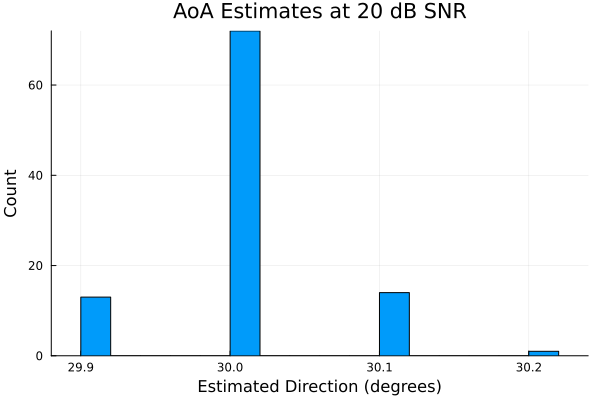

In [143]:
histogram(
    estimates,
    bins = 20,
    xlabel = "Estimated Direction (degrees)",
    ylabel = "Count",
    title = "AoA Estimates at 20 dB SNR",
    legend = false
)

The Monte Carlo simulation is repeated over a range of SNR values to investigate how measurement noise affects the direction estimate.

In [144]:
SNR_values = 0:5:50

MAE_values = zeros(length(SNR_values))
RMSE_values = zeros(length(SNR_values))

for s = 1:length(SNR_values)

    SNR_dB = SNR_values[s]
    noise_power = 10^(-SNR_dB / 10)

    estimates_snr = zeros(trials)

    for trial = 1:trials

        recovered_trial = zeros(ComplexF64, N)

        for i = 1:N

            centre_samples = fill(exp(im * common_phase[i]), Ns)

            outer_samples = fill(
                exp(im * (common_phase[i] + phase[i])),
                Ns
            )

            centre_noise = sqrt(noise_power / 2) .* (
                randn(Ns) .+ im .* randn(Ns)
            )

            outer_noise = sqrt(noise_power / 2) .* (
                randn(Ns) .+ im .* randn(Ns)
            )

            centre_noisy = centre_samples + centre_noise
            outer_noisy = outer_samples + outer_noise

            recovered_samples = outer_noisy .* conj.(centre_noisy)

            recovered_trial[i] = mean(recovered_samples)
        end

        score = zeros(length(phi_test_deg))

        for k = 1:length(phi_test_deg)

            phi_test = deg2rad(phi_test_deg[k])

            OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
            phase_test = (2 * π / λ) .* OD_test
            a_test = exp.(im .* phase_test)

            score[k] = abs(sum(conj.(a_test) .* recovered_trial))
        end

        estimates_snr[trial] = phi_test_deg[argmax(score)]
    end

    errors = mod.(estimates_snr .- phi0_deg .+ 180, 360) .- 180

    MAE_values[s] = mean(abs.(errors))
    RMSE_values[s] = sqrt(mean(errors .^ 2))

    println(
        SNR_dB, " dB: MAE = ",
        round(MAE_values[s], digits=3),
        "°, RMSE = ",
        round(RMSE_values[s], digits=3), "°"
    )
end

0 dB: MAE = 0.45°, RMSE = 0.583°
5 dB: MAE = 0.233°, RMSE = 0.308°
10 dB: MAE = 0.126°, RMSE = 0.17°
15 dB: MAE = 0.057°, RMSE = 0.085°
20 dB: MAE = 0.031°, RMSE = 0.056°
25 dB: MAE = 0.009°, RMSE = 0.03°
30 dB: MAE = 0.0°, RMSE = 0.0°
35 dB: MAE = 0.0°, RMSE = 0.0°
40 dB: MAE = 0.0°, RMSE = 0.0°
45 dB: MAE = 0.0°, RMSE = 0.0°
50 dB: MAE = 0.0°, RMSE = 0.0°


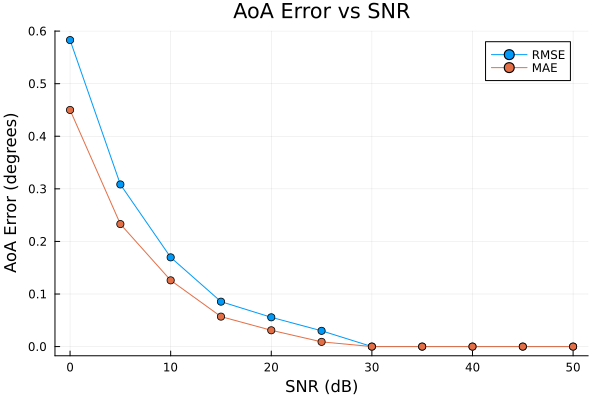

In [149]:
plot(
    SNR_values,
    RMSE_values,
    marker = :circle,
    xlabel = "SNR (dB)",
    ylabel = "AoA Error (degrees)",
    label = "RMSE",
    title = "AoA Error vs SNR"
)

plot!(
    SNR_values,
    MAE_values,
    marker = :circle,
    label = "MAE"
)

## 5. Switch-Path Phase Error## 5. Switch-Path Phase Error

Each switched RF path may introduce a different fixed phase offset. These offsets are added to the outer-antenna measurements to investigate whether they are removed by centre referencing.

Unlike the common signal phase, these path-dependent phase offsets remain after centre referencing and can therefore bias the direction estimate.

In [150]:
# Fixed phase error introduced by each switch path
switch_phase_deg = [2, -3, 1, 0, -2, 3]
switch_phase = deg2rad.(switch_phase_deg)

# Outer signal now contains both direction phase and switch-path phase error
outer_switch = exp.(im .* (common_phase .+ phase .+ switch_phase))

# Centre referencing
recovered_switch = outer_switch .* conj.(centre_signal)

6-element Vector{ComplexF64}:
  -0.3420201433256692 + 0.9396926207859083im
  -0.2588190451025216 + 0.965925826289068im
   0.9998476951563912 + 0.01745240643728377im
   -0.309016994374948 - 0.9510565162951534im
 -0.34202014332566943 - 0.9396926207859081im
   0.9986295347545739 + 0.05233595624294149im

In [151]:
for i = 1:N

    expected = rad2deg(angle(exp(im * phase[i])))
    recovered_phase = rad2deg(angle(recovered_switch[i]))

    println(
        "Antenna ", i,
        ": expected = ", round(expected, digits=2),
        "°, recovered = ", round(recovered_phase, digits=2),
        "°, error = ", switch_phase_deg[i], "°"
    )
end

Antenna 1: expected = 108.0°, recovered = 110.0°, error = 2°
Antenna 2: expected = 108.0°, recovered = 105.0°, error = -3°
Antenna 3: expected = 0.0°, recovered = 1.0°, error = 1°
Antenna 4: expected = -108.0°, recovered = -108.0°, error = 0°
Antenna 5: expected = -108.0°, recovered = -110.0°, error = -2°
Antenna 6: expected = -0.0°, recovered = 3.0°, error = 3°


In [152]:
# The centre reference common phase was removed, but the switching phase was not. So we basically want to see
# the effect of this on the estimation of the Angle of arrival

score = zeros(length(phi_test_deg))

for k = 1:length(phi_test_deg)

    phi_test = deg2rad(phi_test_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test
    a_test = exp.(im .* phase_test)

    score[k] = abs(sum(conj.(a_test) .* recovered_switch))
end

phi_est = phi_test_deg[argmax(score)]

error = mod(phi_est - phi0_deg + 180, 360) - 180

println("True direction      = ", phi0_deg, " degrees")
println("Estimated direction = ", phi_est, " degrees")
println("AoA error           = ", error, " degrees")

True direction      = 30 degrees
Estimated direction = 29.5 degrees
AoA error           = -0.5 degrees


A calibration correction is applied using the known phase offset of each switch path. The corrected antenna phases are then used again for direction estimation.

In [153]:
# There is a need for "calibration"

recovered_calibrated = recovered_switch .* exp.(-im .* switch_phase)

for i = 1:N
    expected = rad2deg(angle(exp(im * phase[i])))
    calibrated_phase = rad2deg(angle(recovered_calibrated[i]))

    println(
        "Antenna ", i,
        ": expected = ", round(expected, digits=2),
        "°, calibrated = ", round(calibrated_phase, digits=2), "°"
    )
end

Antenna 1: expected = 108.0°, calibrated = 108.0°
Antenna 2: expected = 108.0°, calibrated = 108.0°
Antenna 3: expected = 0.0°, calibrated = 0.0°
Antenna 4: expected = -108.0°, calibrated = -108.0°
Antenna 5: expected = -108.0°, calibrated = -108.0°
Antenna 6: expected = -0.0°, calibrated = -0.0°


In [154]:
# Checking the Angle of Arrival after the "calibration"
score = zeros(length(phi_test_deg))

for k = 1:length(phi_test_deg)

    phi_test = deg2rad(phi_test_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test
    a_test = exp.(im .* phase_test)

    score[k] = abs(sum(conj.(a_test) .* recovered_calibrated))
end

phi_est = phi_test_deg[argmax(score)]

error = mod(phi_est - phi0_deg + 180, 360) - 180

println("True direction      = ", phi0_deg, " degrees")
println("Estimated direction = ", phi_est, " degrees")
println("AoA error           = ", error, " degrees")

True direction      = 30 degrees
Estimated direction = 30.0 degrees
AoA error           = 0.0 degrees


## 6. Combined Noise and Switch-Path Error

The previous effects are now combined. Independent measurement noise is added to both receive channels while each switched path also contains its fixed phase offset.

The samples are centre-referenced and averaged, after which the switch-path calibration is applied before direction estimation.

In [155]:
SNR_dB = 20
noise_power = 10^(-SNR_dB / 10)

recovered_combined = zeros(ComplexF64, N)

for i = 1:N

    # Centre-reference samples
    centre_samples = fill(exp(im * common_phase[i]), Ns)

    # Outer samples include direction phase and switch-path phase error
    outer_samples = fill(exp(im * (common_phase[i] + phase[i] + switch_phase[i])), Ns)

    # Add independent noise to both receive channels
    centre_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

    outer_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

    centre_noisy = centre_samples + centre_noise
    outer_noisy = outer_samples + outer_noise

    # Centre-reference and average
    recovered = mean(outer_noisy .* conj.(centre_noisy))

    # Correct the known switch-path phase error
    recovered_combined[i] =
        recovered * exp(-im * switch_phase[i])
end

In [156]:
for i = 1:N

    expected = rad2deg(angle(exp(im * phase[i])))
    recovered_phase = rad2deg(angle(recovered_combined[i]))

    println(
        "Antenna ", i,
        ": expected = ", round(expected, digits=2),
        "°, recovered = ", round(recovered_phase, digits=2), "°"
    )
end

Antenna 1: expected = 108.0°, recovered = 108.14°
Antenna 2: expected = 108.0°, recovered = 107.83°
Antenna 3: expected = 0.0°, recovered = -0.23°
Antenna 4: expected = -108.0°, recovered = -107.98°
Antenna 5: expected = -108.0°, recovered = -107.86°
Antenna 6: expected = -0.0°, recovered = 0.1°


In [157]:
score = zeros(length(phi_test_deg))

for k = 1:length(phi_test_deg)

    phi_test = deg2rad(phi_test_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test
    a_test = exp.(im .* phase_test)

    score[k] = abs(sum(conj.(a_test) .* recovered_combined))
end

phi_est = phi_test_deg[argmax(score)]

error = mod(phi_est - phi0_deg + 180, 360) - 180

println("True direction      = ", phi0_deg, " degrees")
println("Estimated direction = ", phi_est, " degrees")
println("AoA error           = ", error, " degrees")

True direction      = 30 degrees
Estimated direction = 29.9 degrees
AoA error           = -0.09999999999999432 degrees


In [158]:
trials = 100
estimates_combined = zeros(trials)

for trial = 1:trials

    recovered_trial = zeros(ComplexF64, N)

    for i = 1:N

        centre_samples = fill(exp(im * common_phase[i]),Ns)

        outer_samples = fill(exp(im * (common_phase[i] + phase[i] + switch_phase[i])), Ns)

        centre_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

        outer_noise = sqrt(noise_power / 2) .* (randn(Ns) .+ im .* randn(Ns))

        centre_noisy = centre_samples + centre_noise
        outer_noisy = outer_samples + outer_noise

        recovered = mean(outer_noisy .* conj.(centre_noisy))

        recovered_trial[i] = recovered * exp(-im * switch_phase[i])
    end

    score = zeros(length(phi_test_deg))

    for k = 1:length(phi_test_deg)

        phi_test = deg2rad(phi_test_deg[k])

        OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
        phase_test = (2 * π / λ) .* OD_test
        a_test = exp.(im .* phase_test)

        score[k] = abs(sum(conj.(a_test) .* recovered_trial))
    end

    estimates_combined[trial] =
        phi_test_deg[argmax(score)]
end

In [159]:
errors_combined = mod.(estimates_combined .- phi0_deg .+ 180, 360) .- 180

println("First 10 errors = ", errors_combined[1:10])

MAE_combined = mean(abs.(errors_combined))
RMSE_combined = sqrt(mean(errors_combined .^ 2))

println("Combined MAE  = ", round(MAE_combined, digits=3), " degrees")
println("Combined RMSE = ", round(RMSE_combined, digits=3), " degrees")

First 10 errors = [-0.09999999999999432, 0.0, 0.09999999999999432, 0.09999999999999432, 0.0, 0.09999999999999432, 0.09999999999999432, 0.09999999999999432, 0.09999999999999432, 0.0]
Combined MAE  = 0.04 degrees
Combined RMSE = 0.063 degrees
